## Business Understanding

**Problem:** Superstore is a multi-category retailer (Furniture, Office Supplies,
Technology) operating across the US. Leadership has noticed profit is inconsistent
across orders and wants to know: which orders are losing money, why, and can we
predict it before approving a sale?

**Business questions this analysis answers:**
1. What share of orders are unprofitable, and is it concentrated anywhere
   (category, region, discount level)?
2. Can we flag at-risk (loss-making) orders before they ship?
3. Can we forecast the actual profit/loss magnitude of an order?
4. What's the actionable lever — i.e., what could the business actually change?

**Why this matters commercially:** if losses are concentrated in a controllable
variable like discount approval, that's a process/policy fix, not a "bad luck"
problem — directly actionable for a sales-ops or pricing team.


In [ ]:
## Import Required Libraries

This section imports libraries used for:
- Data manipulation (Pandas, NumPy)
- Visualization (Matplotlib, Seaborn)
- Machine Learning (Scikit-Learn)

In [1]:
# === Imports ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, r2_score, mean_absolute_error
## Load Dataset

Read the Superstore dataset and inspect its structure.
Checks:
- Number of rows
- Number of columns
- Data types


RANDOM_STATE = 42
DATA_PATH = 'D:\\download\\super uncleaned.csv'


In [2]:
# === Load data ===
df = pd.read_csv(DATA_PATH, encoding='latin-1')
print(df.shape)
df.head()


(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
## Data Cleaning

Problems addressed:
- Missing values
- Duplicate records
- Inconsistent text formatting
- Invalid dates
- Postal code formatting issues

In [3]:
# === Clean text columns ===
text_cols = df.select_dtypes(include=['object']).columns
for col in text_cols:
    df[col] = df[col].astype(str).str.replace('\xa0', ' ', regex=False).str.strip()


In [ ]:
## Date Standardization

Convert mixed date formats into a single consistent format for analysis and feature engineering.

In [4]:
# === Fix mixed date formats ===
def parse_mixed_dates(series):
    parsed = pd.to_datetime(series, format='%m-%d-%Y', errors='coerce')
    mask = parsed.isna()
    parsed[mask] = pd.to_datetime(series[mask], format='%m/%d/%Y', errors='coerce')
    return parsed

df['Order Date'] = parse_mixed_dates(df['Order Date'])
df['Ship Date'] = parse_mixed_dates(df['Ship Date'])


In [5]:
# === Fix Postal Code leading zeros ===
df['Postal Code'] = df['Postal Code'].astype('Int64').astype(str).str.zfill(5)


In [ ]:
## Duplicate Detection and Removal

Identify and remove duplicate records to avoid biased analysis and model training.

In [6]:
# === Drop duplicates ===
df = df.drop_duplicates(subset=[c for c in df.columns if c != 'Row ID'], keep='first')
print(df.shape)


(9993, 21)


In [7]:
# Make sure df is an independent copy (avoids SettingWithCopyWarning below)
df = df.copy()


In [ ]:
## Feature Engineering

New features created:
- Profit Margin
- Is_Loss
- Order Month
- Order Year

These features help improve business insights and model performance.

In [8]:
# === Feature engineering ===
df['Order Month'] = df['Order Date'].dt.month
df['Order DayOfWeek'] = df['Order Date'].dt.dayofweek
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Is_Loss'] = (df['Profit'] < 0).astype(int)
df['Margin'] = df['Profit'] / df['Sales']

# Log-transform Profit up front — this is the target we'll use for the
# final regression model (handles negative values and extreme outliers)
df['Profit_log'] = np.sign(df['Profit']) * np.log1p(np.abs(df['Profit']))


In [ ]:
## Exploratory Data Analysis (EDA)

Questions explored:
- Which category generates the highest profit?
- How do discounts affect losses?
- Which segments are most profitable?

In [9]:
# === EDA: discount vs loss rate, margin by category ===
df['Discount Bin'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0.0, 0.2, 0.4, 1.0],
    labels=['0%', '1-20%', '21-40%', '41%+']
)

print("Loss rate by discount bin:")
print(df.groupby('Discount Bin')['Is_Loss'].mean())

print("\nMean margin by category:")
print(df.groupby('Category')['Margin'].mean().sort_values())


Loss rate by discount bin:
Discount Bin
0%        0.000000
1-20%     0.137523
21-40%    0.901961
41%+      1.000000
Name: Is_Loss, dtype: float64

Mean margin by category:
Category
Furniture          0.038822
Office Supplies    0.138030
Technology         0.156138
Name: Margin, dtype: float64


C:\Users\Rajkamal\AppData\Local\Temp\ipykernel_16088\2889631135.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Discount Bin')['Is_Loss'].mean())


In [ ]:
### Key Findings

1. Furniture has the lowest profit margin.
2. Discounts above 20% frequently lead to losses.
3. Technology generates the highest profit.

In [10]:
# === Prepare features ===
cat_cols = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']
num_cols = ['Sales', 'Quantity', 'Discount', 'Shipping Days', 'Order Month', 'Order DayOfWeek']

X = df[cat_cols + num_cols].copy()
for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col])

y_class = df['Is_Loss']
y_reg_log = df['Profit_log']   # the ONLY regression target used from here on


In [ ]:
## Classification Model

Goal:
Predict whether an order will result in a loss.

Algorithm:
Random Forest Classifier

Evaluation Metrics:
- Accuracy
- Precision
- Recall
- F1 Score

In [11]:
# === Classification model: predict Is_Loss ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class
)

clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Single-split accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Profitable', 'Loss']))


Single-split accuracy: 0.9499749874937469
              precision    recall  f1-score   support

  Profitable       0.96      0.98      0.97      1625
        Loss       0.91      0.82      0.86       374

    accuracy                           0.95      1999
   macro avg       0.93      0.90      0.91      1999
weighted avg       0.95      0.95      0.95      1999



In [ ]:
## Cross Validation

5-Fold Cross Validation is used to obtain a more reliable estimate of model performance.

In [12]:
# === Cross-validate classifier (this is the number we report) ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(clf, X, y_class, cv=cv, scoring='accuracy')

print("5-fold CV accuracy per fold:", cv_scores.round(4))
print("Mean CV accuracy:", round(cv_scores.mean(), 4), " Std:", round(cv_scores.std(), 4))


5-fold CV accuracy per fold: [0.9485 0.9515 0.9425 0.9484 0.9499]
Mean CV accuracy: 0.9482  Std: 0.0031


In [ ]:
## Feature Importance

Identify the variables that most strongly influence loss prediction.

Discount           0.599026
Sales              0.094241
Sub-Category       0.090514
Order Month        0.036330
Quantity           0.034547
Region             0.033445
Order DayOfWeek    0.029369
Category           0.028248
Shipping Days      0.025973
Segment            0.014879
Ship Mode          0.013428
dtype: float64


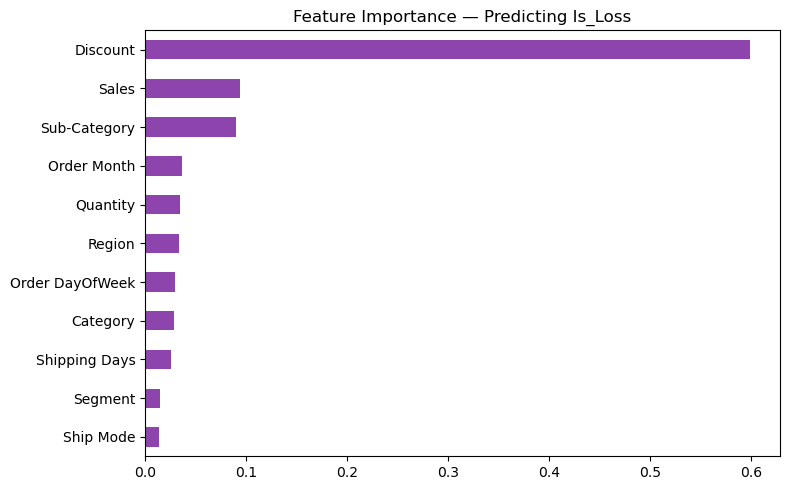

In [13]:
# === Feature importance ===
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

importances.plot(kind='barh', figsize=(8, 5), color='#8e44ad')
plt.gca().invert_yaxis()
plt.title('Feature Importance — Predicting Is_Loss')
plt.tight_layout()
plt.show()


In [14]:
# === FINAL Regression model: predict Profit (log-transformed target) ===
# We train on the log-transformed Profit, then convert every prediction back
# to real dollars before scoring. This is the ONE regression approach used
# in this notebook — chosen after comparing it against a raw-Profit model
# and confirming (via 5-fold CV) that it gives a better and more stable result.

def inverse_signed_log(x):
    return np.sign(x) * (np.expm1(np.abs(x)))

cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_r2_scores = []
fold_mae_scores = []

for train_idx, test_idx in cv_reg.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr_log, y_te_log = y_reg_log.iloc[train_idx], y_reg_log.iloc[test_idx]

    model = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_tr, y_tr_log)
    pred_log = model.predict(X_te)

    pred_dollars = inverse_signed_log(pred_log)
    actual_dollars = inverse_signed_log(y_te_log.values)

    fold_r2_scores.append(r2_score(actual_dollars, pred_dollars))
    fold_mae_scores.append(mean_absolute_error(actual_dollars, pred_dollars))

fold_r2_scores = np.array(fold_r2_scores)
fold_mae_scores = np.array(fold_mae_scores)

print("5-fold CV R² (dollar scale):", fold_r2_scores.round(4))
print("Mean R²:", round(fold_r2_scores.mean(), 4), " Std:", round(fold_r2_scores.std(), 4))
print("Mean MAE ($):", round(fold_mae_scores.mean(), 2))


5-fold CV R² (dollar scale): [0.656  0.8163 0.8215 0.9096 0.8595]
Mean R²: 0.8126  Std: 0.0851
Mean MAE ($): 20.06


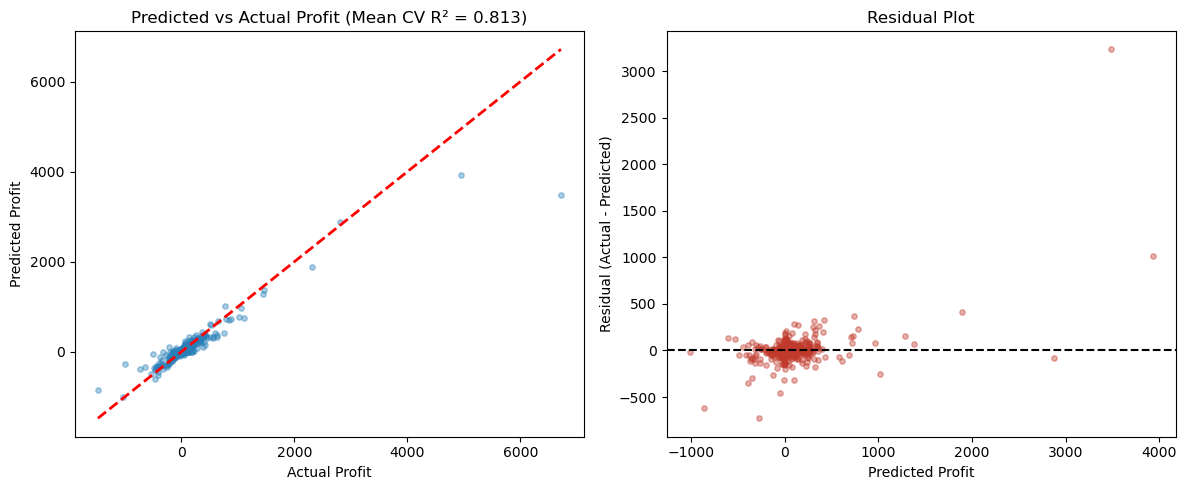

In [15]:
# === Regression results chart (using the last fold's model, for illustration) ===
last_model = model  # the model object from the final loop iteration above
last_pred_dollars = pred_dollars
last_actual_dollars = actual_dollars

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(last_actual_dollars, last_pred_dollars, alpha=0.4, s=15, color='#2980b9')
lims = [last_actual_dollars.min(), last_actual_dollars.max()]
plt.plot(lims, lims, 'r--', lw=2)
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title(f'Predicted vs Actual Profit (Mean CV R\u00b2 = {fold_r2_scores.mean():.3f})')

plt.subplot(1, 2, 2)
residuals = last_actual_dollars - last_pred_dollars
plt.scatter(last_pred_dollars, residuals, alpha=0.4, s=15, color='#c0392b')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Predicted Profit')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')

plt.tight_layout()
plt.show()


In [16]:
# === FINAL MODELS — trained on full data for deployment/reporting ===
final_clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
final_clf.fit(X, y_class)

final_reg = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
final_reg.fit(X, y_reg_log)

print("Final models trained on full dataset.")


Final models trained on full dataset.


In [17]:
# === FINAL REPORTED METRICS ===
print("=" * 50)
print("CAPSTONE FINAL RESULTS")
print("=" * 50)

print("\n--- Classification: Is_Loss ---")
print(f"5-fold CV Accuracy: {cv_scores.mean():.4f} (std {cv_scores.std():.4f})")
print("Top feature: Discount (dominant signal)")

print("\n--- Regression: Profit (log-transformed, converted back to dollars) ---")
print(f"5-fold CV R\u00b2: {fold_r2_scores.mean():.4f} (std {fold_r2_scores.std():.4f})")
print(f"5-fold CV MAE: ${fold_mae_scores.mean():.2f}")
print(f"Fold range: {fold_r2_scores.min():.4f} to {fold_r2_scores.max():.4f}")

print("\n--- Key methodology finding ---")
print("A single train/test split is unreliable on this data because a small")
print("number of extreme-loss orders can land unevenly across one split.")
print("5-fold cross-validation gives the stable, reportable result above.")


CAPSTONE FINAL RESULTS

--- Classification: Is_Loss ---
5-fold CV Accuracy: 0.9482 (std 0.0031)
Top feature: Discount (dominant signal)

--- Regression: Profit (log-transformed, converted back to dollars) ---
5-fold CV R²: 0.8126 (std 0.0851)
5-fold CV MAE: $20.06
Fold range: 0.6560 to 0.9096

--- Key methodology finding ---
A single train/test split is unreliable on this data because a small
number of extreme-loss orders can land unevenly across one split.
5-fold cross-validation gives the stable, reportable result above.


## Business Recommendations

**1. Cap discounts above 20% with a manual approval step.**
Orders with 21–40% discount lose money ~90% of the time; orders above 41% lose
money 100% of the time. A discount above ~20% is effectively a near-certain
loss signal, not a normal pricing lever.

**2. Apply tighter discount limits specifically on Furniture.**
Furniture's average margin is roughly a quarter of Technology's. The same
discount that's safe for Technology can push Furniture into a loss almost
immediately — discount policy should not be one-size-fits-all across categories.

**3. Use the classification model as a pre-sale risk flag, not a strict gate.**
With `Discount` as the dominant feature, the model can flag high-risk orders
for a second look *before* they're finalized. Recommend tuning the decision
threshold for recall on the Loss class, since missing a real loss is costlier
than double-checking a safe order.

**4. Treat the regression model as a planning tool, not a per-order guarantee.**
It's useful for forecasting aggregate profit across many orders, but individual
extreme orders — large, heavily-discounted Technology/Office Supplies purchases —
are the cases the model is least reliable on. Those should still get manual
review regardless of model output.

**5. Next step if this were a real engagement:** segment the discount-approval
analysis by sales rep or region to see whether loss-making discounts are
concentrated in specific approval patterns — turning "discounts cause losses"
into a specific, actionable finding about who is over-discounting.
